In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings

if '../' not in sys.path:
    sys.path.append('../')

from functools import partial
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

from mcp_boltzmann import annihilation as ann
from mcp_boltzmann.boltzmann import Boltzmann

warnings.filterwarnings("ignore")

In [3]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

In [4]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

### MCP model parameters

In [5]:
shelton_Q_mass_027 = load_csv('../input/fig/2206.13530_fig3_DNE_027.csv')
shelton_Q_of_M = interp1d(shelton_Q_mass_027[0], shelton_Q_mass_027[1])

In [6]:
MeV = 1
GeV = 1e3

In [7]:
m_mcp = 10000.0*MeV
# m_mcp = 100.0*MeV

Q = shelton_Q_of_M(m_mcp)
# Q = 2.7e-9

c_theta_w = 0.881255
eps_VR = 1e-9

Q = eps_VR/c_theta_w
# Q = eps_VR
# Q = 2e-8
Q = 8e-5

In [8]:
print(f'{Q=}')

Q=8e-05


## Annihilation Collision terms

In [9]:
from mcp_boltzmann.annihilation import load_ann_rate

_CF_ff_xx_I = load_ann_rate(
    f'../output/rates/annihilation/mcp_annihilation_rate_m_{m_mcp}_Q_1.npz'
)

In [10]:
#total annihilation rate from sm to dark sector
def CF_ann(T, Q):
    return Q**2*_CF_ff_xx_I(T)

def CF_ann_sm_ds(T_sm, T_ds, Q):
    return CF_ann(T_sm, Q) - CF_ann(T_ds, Q)

## Coulomb Scattering

In [11]:
from mcp_boltzmann.elastic_scattering import load_tabulated_rate

mcp_coulomb_rate = load_tabulated_rate(f'../output/rates/coulomb/mcp_coulomb_rate_m_{m_mcp}_Q_1.npz')
# mcp_coulomb_rate_F = load_tabulated_rate(f'../output/rates/coulomb/test/mcp_coulomb_rate_m_{m_mcp}_Q_1_F.npz')

In [12]:
def CF_scatt_sm_ds(T_sm, T_ds, Q):
    return Q**2*mcp_coulomb_rate(T_sm, T_ds)

def CF_scatt_sm_ds_F(T_sm, T_ds, Q):
    return Q**2*mcp_coulomb_rate_F(T_sm, T_ds)

## Plasmon Decay

In [13]:
from mcp_boltzmann import plasma as plas
def CF_plas(T_sm, T_ds, Q):
    T_EW = 160*GeV
    pdecay = np.heaviside(T_EW - T_sm, 0)*plas.C_plasmon(T_sm, T_ds, m_mcp, Q) 
    bdecay = np.heaviside(T_sm - T_EW, 1)*plas.C_B_decay(T_sm, T_ds, m_mcp, Q)
    return pdecay + bdecay

### Z decay

In [14]:
def CF_Z_decay(T_sm, T_ds, Q):
    return plas.C_Z_decay(T_sm, T_ds, m_mcp, Q)

# Setup Boltzmann equation

In [15]:
Boltz = Boltzmann(m_mcp, Q)
Boltz.add_colterm_EM_DS(CF_ann_sm_ds)
Boltz.add_colterm_EM_DS(CF_scatt_sm_ds)
Boltz.add_colterm_EM_DS(CF_plas)
Boltz.add_colterm_EM_DS(CF_Z_decay)

In [16]:
from mcp_boltzmann.sm import DeltaRho_nue, DeltaRho_numu

FAC = 1./(6.58212e-22)

def delta_rho_nu_gam(T_gam, T_nu):
    return (1/FAC)*(DeltaRho_nue(T_gam, T_nu, 0.0) + 2*DeltaRho_numu(T_gam, T_nu, 0.0))

In [27]:
T_gamma_0 = 1e6 * MeV
T_nu_0 = T_gamma_0
T_DS_0 = 3.5e2
T_DS_0 = 1e6

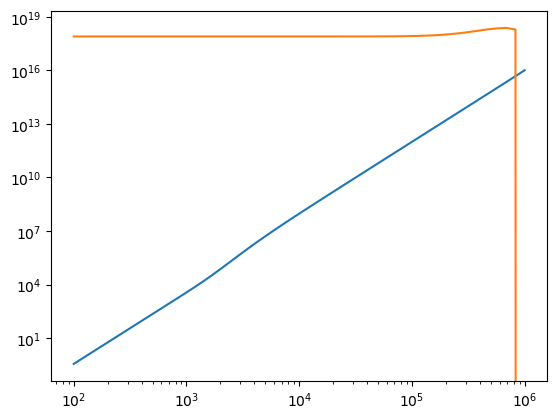

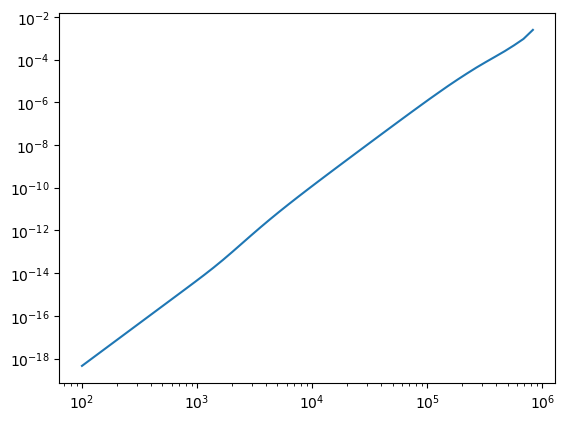

In [28]:
from mcp_boltzmann import boltzmann
from mcp_boltzmann.boltzmann import rho_DS
T_DS_test = np.geomspace(1e2, 1e6)

4*boltzmann.Hubble(T_gamma_0, T_gamma_0, T_DS_0, m_mcp)*rho_DS(T_DS_0, m_mcp)
Boltz.colterm_EM_DS(T_gamma_0, T_DS_0)

plt.plot(T_DS_test, 4*boltzmann.Hubble(T_gamma_0, T_gamma_0, T_DS_test, m_mcp)*rho_DS(T_DS_test, m_mcp))
plt.plot(T_DS_test, Boltz.colterm_EM_DS(T_gamma_0, T_DS_test))
plt.yscale('log')
plt.xscale('log')
plt.show()

R = 4*boltzmann.Hubble(T_gamma_0, T_gamma_0, T_DS_test, m_mcp)*rho_DS(T_DS_test, m_mcp)/Boltz.colterm_EM_DS(T_gamma_0, T_DS_test)

plt.plot(T_DS_test, R)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [29]:
sol_sm = Boltz.solve_boltzmann_eq_SM(T_gamma_0, T_nu_0)
Boltz.N_eff_SM(sol_sm.y[0][-1], sol_sm.y[1][-1])

3.0305937156100193

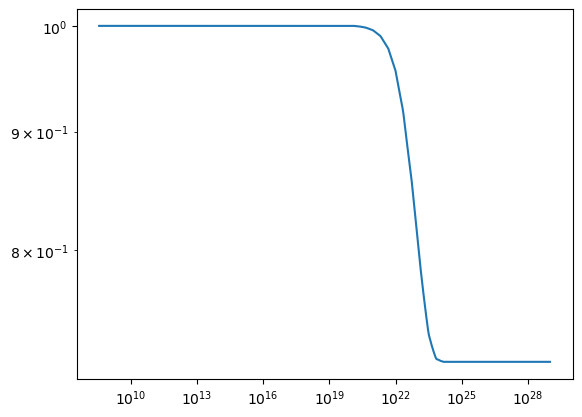

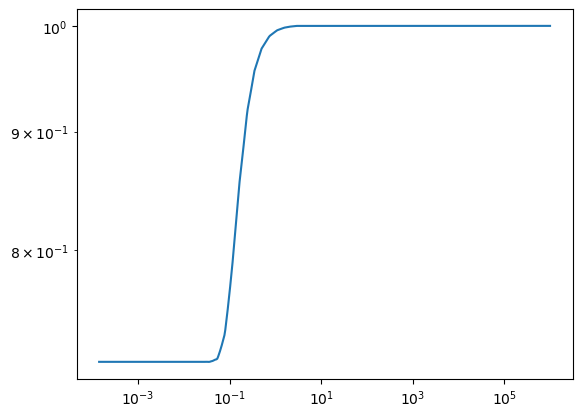

In [30]:
plt.plot(sol_sm.t, sol_sm.y[1]/sol_sm.y[0])
plt.xscale('log')
plt.yscale('log')

plt.show()

plt.plot(sol_sm.y[0], sol_sm.y[1]/sol_sm.y[0])
plt.xscale('log')
plt.yscale('log')

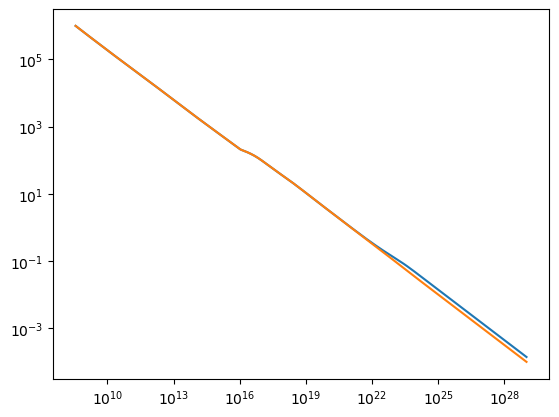

In [31]:
plt.plot(sol_sm.t, sol_sm.y[0])
plt.plot(sol_sm.t, sol_sm.y[1])
plt.xscale('log')
plt.yscale('log')

plt.show()

In [ ]:
sol_bsm = Boltz.solve_boltzmann_eq(T_gamma_0, T_nu_0, T_DS_0)

T_gam_final = sol_bsm.y[0][-1]
T_nu_final = sol_bsm.y[1][-1]
T_ds_final = sol_bsm.y[2][-1]

In [39]:
Boltz.dT_neutrino_dt(0.99, 0.99, 0.45133248)

array([-4.33095605e-22])

## Neff

In [ ]:
from mcp_boltzmann.boltzmann import rho_DS, rho_EM, rho_neutrino

def Delta_Neff_lazy(T_gam, T_ds, m_mcp):
    return (8/7)*(11/4)**(4/3)*(rho_DS(T_ds, m_mcp)/rho_EM(T_gam))

In [ ]:
print(Delta_Neff_lazy(T_gam_final, T_ds_final, m_mcp))

In [ ]:
N_eff_bsm = Boltz.N_eff(sol_bsm.y[0][-1], sol_bsm.y[1][-1], sol_bsm.y[2][-1])
N_eff_sm = Boltz.N_eff_SM(sol_sm.y[0][-1], sol_sm.y[1][-1])
Delta_Neff = N_eff_bsm - N_eff_sm 

In [ ]:
print(f'{N_eff_sm=}')
print(f'{N_eff_bsm=}')
print(f'{Delta_Neff=}')

In [ ]:
sol_sm.y[1][-1]/sol_sm.y[0][-1]

In [ ]:
plt.plot(sol_sm.t, sol_sm.y[0])
plt.plot(sol_sm.t, sol_sm.y[1])
plt.yscale('log')
plt.xscale('log')

## Temperature Evolution

In [ ]:
plt.plot(sol_bsm.t, sol_bsm.y[0], label=r'T$_\gamma$')
plt.plot(sol_bsm.t, sol_bsm.y[1], label=r'T$_{\nu}$')
plt.plot(sol_bsm.t, sol_bsm.y[2], label=r'T$_{\rm ds}$')

plt.plot(sol_bsm.t, sol_bsm.y[0][0]*np.sqrt(sol_bsm.t[0]/sol_bsm.t), linestyle='dashed', color='black', alpha=0.5)
plt.plot(sol_bsm.t, sol_bsm.y[1][-1]*np.sqrt(sol_bsm.t[-1]/sol_bsm.t), linestyle='dashed', color='black', alpha=0.5)

plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


plt.plot(sol_bsm.y[0], sol_bsm.y[0], label=r'T$_\gamma$')
plt.plot(sol_bsm.y[0], sol_bsm.y[1], label=r'T$_{\nu}$')
plt.plot(sol_bsm.y[0], sol_bsm.y[2], label=r'T$_{\rm ds}$')


plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


In [ ]:
fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig3_left_Td_by_Tgam.csv')

In [ ]:
plt.plot(sol_bsm.t, sol_bsm.y[1]/sol_bsm.y[0], label=r'T$_\nu$/T$_\gamma$')
plt.plot(sol_bsm.t, sol_bsm.y[2]/sol_bsm.y[0], label=r'T$_{\rm dark}$/T$_\gamma$')
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Time [MeV$^{-1}$]')
plt.title('Temperature Ratio')

plt.tick_params(labelright=True, which='both')
plt.yticks()
plt.grid(which='both', axis='y')
plt.grid(axis='x')

plt.legend()

plt.show()

plt.plot(sol_bsm.y[0], sol_bsm.y[1]/sol_bsm.y[0], label=r'T$_\nu$/T$_\gamma$')
plt.plot(sol_bsm.y[0], sol_bsm.y[2]/sol_bsm.y[0], label=r'T$_{\rm dark}$/T$_\gamma$')
plt.plot(*fig3_1311_2600_Td_by_Tgam)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('T$_\gamma$ [MeV]')
plt.title('Temperature Ratio')

plt.tick_params(labelright=True, which='both')
plt.yticks()
plt.grid(which='both', axis='y')
plt.grid(axis='x')
plt.gca().invert_xaxis()


plt.ylim(1e-2, 1.1)
# plt.axvline(200,  color='purple', linestyle='dashed', alpha=0.5, label=r'$\Lambda_{\rm QCD}$')
plt.axvline(150,  color='purple', linestyle='dashed', alpha=0.5)
# plt.xlim(0.8e4, 1.1e-2)
plt.legend()

plt.show()

In [ ]:
from mcp_boltzmann.gstar import gstar_E_EM, gstar_P_EM

def g_star_s(E):
    return 0.25*(3*gstar_E_EM(E) + gstar_P_EM(E))

(g_star_s(150)/g_star_s(200))**(1/3)

### Try calcing the temerapture ratio from the first peak at around 300 MeV to the trough

In [ ]:
plt.plot(sol_bsm.y[0], sol_bsm.y[0], linestyle='dashed', color='black', alpha=0.8, label=r'T$_\gamma$')
plt.plot(sol_bsm.y[0], sol_bsm.y[1], label=r'T$_\nu$')
plt.plot(sol_bsm.y[0], sol_bsm.y[2], label=r'T$_{\rm dark}$')
plt.yscale('log')
plt.xscale('log')

plt.xlabel(r'T$_{\gamma}$ [MeV]')
plt.ylabel('T [MeV]')
plt.title('Temperature Ratio')
plt.legend()

plt.gca().invert_xaxis()

plt.show()

In [ ]:
from mcp_boltzmann.boltzmann import Hubble
Hub_plot = Hubble(sol_bsm.y[0], sol_bsm.y[1], sol_bsm.y[2], m_mcp)
plt.plot(sol_bsm.t, np.abs(CF_plas(sol_bsm.y[0], sol_bsm.y[2], Q)/Hub_plot), label='Plasmon Decay')
plt.plot(sol_bsm.t, np.abs(CF_ann_sm_ds(sol_bsm.y[0], sol_bsm.y[2], Q)/Hub_plot), label='Annihilation')
plt.plot(sol_bsm.t, np.abs(CF_scatt_sm_ds(sol_bsm.y[0], sol_bsm.y[2], Q)/Hub_plot), label='Scattering')
plt.plot(sol_bsm.t, np.abs(CF_Z_decay(sol_bsm.y[0], sol_bsm.y[2], Q)/Hub_plot), label='Z boson decay')

plt.legend()
plt.yscale('log')
plt.xscale('log')

plt.ylabel(r'Rate')
plt.xlabel(r'Time [MeV$^{-1}$]')

plt.ylim(1e-5, 1e20)

plt.show()

In [ ]:
plt.plot(sol_bsm.y[0], CF_plas(sol_bsm.y[0], sol_bsm.y[2], Q)/sol_bsm.y[0]**6, label='plasmon decay')
plt.plot(sol_bsm.y[0], CF_Z_decay(sol_bsm.y[0], sol_bsm.y[2], Q)/sol_bsm.y[0]**6, label='Z decay')
plt.plot(sol_bsm.y[0], CF_ann_sm_ds(sol_bsm.y[0], sol_bsm.y[2], Q)/sol_bsm.y[0]**6, label='annihilation')
plt.plot(sol_bsm.y[0], CF_scatt_sm_ds(sol_bsm.y[0], sol_bsm.y[2], Q)/sol_bsm.y[0]**6, label='scattering')
plt.ylim(1e-28, 1e-22)

plt.axvline(200,  color='purple', linestyle='dashed', alpha=0.5, label=r'$\Lambda_{\rm QCD}$')
plt.axvline(m_mcp, color='black', linestyle='dotted', label=r'$m_{\rm mcp}$')

plt.yscale('log')
plt.xscale('log')

plt.legend(loc='upper right')
plt.gca().invert_xaxis()

plt.xlabel(r'T$_\gamma$ [MeV]')
plt.ylabel(r'C/$T^6_\gamma$ [MeV$^{-1}$]')
plt.show()

In [ ]:
Col_tot = (
    CF_ann_sm_ds(sol_bsm.y[0], sol_bsm.y[2], Q)
   +CF_plas(sol_bsm.y[0], sol_bsm.y[2], Q)
)

Hub_tot = boltzmann.Hubble(sol_bsm.y[0], sol_bsm.y[1],sol_bsm.y[2], m_mcp)*(
    boltzmann.rho_DS(sol_bsm.y[2], m_mcp) + boltzmann.p_DS(sol_bsm.y[2], m_mcp)
)
            

In [ ]:
com_ED = boltzmann.rho_DS(sol_bsm.y[2], m_mcp)*(sol_bsm.y[3])**4
# com_col = Boltz.colterm_EM_DS(sol_bsm.y[0], sol_bsm.y[2])*(sol_bsm.y[3])**4
# com_col = CF_ann(sol_bsm.y[0], Q)*(sol_bsm.y[3])**4
com_col = (
    CF_scatt_sm_ds_F(sol_bsm.y[0], sol_bsm.y[2], Q)
   +CF_ann(sol_bsm.y[0], Q)
   +plas.C_plasmon_forwards(sol_bsm.y[0], m_mcp, Q)
)*(sol_bsm.y[3])**4

H_plot = Hubble(sol_bsm.y[0], sol_bsm.y[1], sol_bsm.y[2], m_mcp)

In [ ]:
i = find_nearest(sol_bsm.y[0], 3000)
(plas.C_plasmon_forwards(sol_bsm.y[0][i], m_mcp, Q)/H_plot[i])*(sol_bsm.y[3][i])**4

In [ ]:
shelton_f2_rho = load_csv('../input/fig/2206.13530_fig2_left_energy.csv')
shelton_f2_cF = load_csv('../input/fig/2206.13530_fig2_left_CF.csv')

## We need to plot the forward energy transfer term here, which needs to be computed for elastic scattering

In [ ]:
#compute comoving energy density for DeltaNeff = 0.3s

In [ ]:
#calculation of dark sector temp that makes Delta N_eff = 0.3 at Tsm = 1e-3 MeV
r = 0.3*(7/8)*(4/11)**(4/3)*boltzmann.rho_EM(1e-3)
T_ds_03 = ((15/np.pi**2)*r)**(1/4)

sf = sol_bsm.y[3][find_nearest(sol_bsm.y[0], 1e-3)]

rho_neff_03 = boltzmann.rho_DS(T_ds_03, m_mcp)*(sf)**4

In [ ]:
plt.plot(sol_bsm.y[0], com_ED)
plt.plot(sol_bsm.y[0], com_col/H_plot)
plt.plot(*shelton_f2_rho)
plt.plot(*shelton_f2_cF)

plt.axhline(rho_neff_03, label=r'$\Delta N_{\rm eff} = 0.3$', linestyle='dashed')
plt.axhline(1.3e-40, label=r'$\Delta N_{\rm eff} = 0.3$', linestyle='dashed', color='gray')

plt.yscale('log')
plt.xscale('log')
plt.axvline(m_mcp/4, linestyle='dashed', color='black')

plt.xlabel(r'T$_{\rm sm}$ [MeV]')
plt.ylabel(r'$\rho_{\rm hs} a^4$')

plt.ylim(1e-42, 1e-39)
plt.xlim(3, 1e4)
plt.show()

In [ ]:
Boltz.Delta_Neff_ds_only(1.0,0.6558587687646521, m_mcp)

In [ ]:
boltzmann.rho_DS(0.0005109025798037535, m_mcp)*(2.3166189794586197e-07)**4

In [ ]:
plt.plot(sol_bsm.y[0], Hub_plot)
plt.axvline(200, linestyle='dashed', color='black')
plt.yscale('log')
plt.xscale('log')

In [ ]:
rho_tot = (
    boltzmann.rho_EM(sol_bsm.y[0]) 
  + boltzmann.rho_neutrino(sol_bsm.y[1]) 
  + boltzmann.rho_DS(sol_bsm.y[2], m_mcp)
)

plt.plot(sol_bsm.y[0], rho_tot*sol_bsm.y[3]**4)


plt.yscale('log')
plt.xscale('log')

In [ ]:
find_nearest(sol_bsm.y[0], 1e-2)
print(sol_bsm.y[3][find_nearest(sol_bsm.y[0], 1e-3)])


In [ ]:
boltzmann.rho_DS(0.6558587687646521, m_mcp)

In [ ]:
(1.3e-40/.12174463)**(1/4)

In [ ]:
1.807687623281379e-10/1.6699605772796134e-10

In [ ]:
Boltz.Delta_Neff_ds_only(1.0,0.6536644627432626, m_mcp)